In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# A. Users

In [2]:
def cleanse_user_plan(plan):
    plan = str(plan).lower()
    if plan in ['enterprise', 'enterprize']:
        return 'enterprise'
    elif plan in ['growht', 'growth']:
        return 'growth'
    elif plan in ['starter']:
        return 'starter'
    else:
        return plan

users_df = pd.read_csv('../data/raw/users.csv')
print('count users: {}'.format(users_df['user_id'].shape[0]))

users_df = users_df.drop_duplicates()
print('count users after dedup: {}'.format(users_df['user_id'].shape[0]))

users_df['plan'] = users_df['plan'].map(lambda x: cleanse_user_plan(x))
users_df.groupby('plan')['user_id'].count()

count users: 225
count users after dedup: 220


plan
enterprise    49
growth        80
starter       91
Name: user_id, dtype: int64

# B. Messages

In [3]:
from nlp.utils import clean_html_escape_characters

messages_df = pd.read_csv('../data/raw/messages.csv')
print('--- Raw messages data --- ')
print('total messages rows: {}'.format(messages_df.shape[0]))
print('messages from ghost: {}'.format(messages_df[messages_df['user_id'].str.contains('ghost')].shape[0]))

# Exorcism: Inner join with users date, to get only valid users and get rid of ghosts
messages_df = messages_df.merge(users_df[['user_id','country']], how='inner', on='user_id').copy()
print('--- After exorcism --- ')
print('total messages rows: {}'.format(messages_df.shape[0]))
print('messages from ghost: {}'.format(messages_df[messages_df['user_id'].str.contains('ghost')].shape[0]))

# Dedup & Standardising
messages_df['content'] = messages_df['content'].map(clean_html_escape_characters) 
messages_df = (
    messages_df.drop_duplicates()
    .sort_values(['user_id', 'conversation_id', 'timestamp'])
    .reset_index(drop=True)
)
messages_df['role'] = messages_df['role'].str.lower()
messages_df['timestamp'] = pd.to_datetime(messages_df['timestamp'])

print('--- After dedup and standardising --- ')
print('total messages rows: {}'.format(messages_df.shape[0]))
messages_df.head()

--- Raw messages data --- 
total messages rows: 13726
messages from ghost: 802
--- After exorcism --- 
total messages rows: 12924
messages from ghost: 0
--- After dedup and standardising --- 
total messages rows: 12742


,message_id,conversation_id,user_id,video_id,role,content,model,timestamp,country
0,msg_001117,conv_03cf567979,usr_009ddeb9,vid_bce2536d0a,user,I want a training video,NaN,2024-06-03 04:50:57,FR
1,msg_001118,conv_03cf567979,usr_009ddeb9,vid_bce2536d0a,assistant,Updated. Let me know if this is closer to what...,gpt-4o-mini,2024-06-03 04:52:52,FR
2,msg_001119,conv_03cf567979,usr_009ddeb9,vid_bce2536d0a,user,update the script and switch to the minimal te...,NaN,2024-06-03 04:55:59,FR
3,msg_001120,conv_03cf567979,usr_009ddeb9,vid_bce2536d0a,assistant,I've revised the video. The changes are reflec...,gpt-4o-mini,2024-06-03 04:57:39,FR
4,msg_012149,conv_1227413fa7,usr_009ddeb9,vid_ac0e078db7,user,I need a video on brand awareness,NaN,2024-12-05 23:27:37,FR


## 1. Unique message content and empty messages

In [4]:
messages_count_by_role = (
    messages_df.groupby('role')
    .agg(
        messages=('message_id', 'count'),
        unique_content=('content', 'nunique'),
        empty_content=('content', lambda x:  (x!=x).sum())
    )
)
messages_count_by_role

,messages,unique_content,empty_content
role,,,
assistant,6371,12,187
user,6371,1093,136


## 2. Duplicate Message Contents

In [5]:
assistant_messages_df = messages_df[messages_df['role']=='assistant']
user_messages_df = messages_df[messages_df['role']=='user']

print(f"All user messages rows: {user_messages_df.shape[0]}")
print(f"Unique user messages content: {user_messages_df['content'].drop_duplicates().shape[0]}")

print('Top-10 Duplicated user messages:')
unique_user_messages_content_df = user_messages_df.groupby(['content']).agg(
    count_messages=('message_id', 'count')
).reset_index()
unique_user_messages_content_df.sort_values('count_messages', ascending=False).head(10).reset_index(drop=True)

All user messages rows: 6371
Unique user messages content: 1094
Top-10 Duplicated user messages:


,content,count_messages
0,the narration is wrong and the visuals don't m...,131
1,rewrite the second section and remove the logo...,129
2,the text is wrong and the colour scheme doesn'...,126
3,change the avatar and also the tone of the nar...,120
4,can you change the opening line to say 'Let's ...,96
5,can you update the script to use simpler langu...,96
6,"rewrite the narration for scene 2, it sounds off",93
7,the closing line should be 'Thank you for watc...,92
8,add a line about our sustainability commitments,87
9,the wording in the middle section needs to change,87


# C. Video

In [6]:
videos_df = pd.read_csv('../data/raw/videos.csv').rename(columns={'creator_id':'user_id'})
print('--- Raw videos data --- ')
print('Videos count rows: {}'.format(videos_df.shape[0]))

ghost_videos_df = videos_df[videos_df['user_id'].str.contains('ghost')]
print('Ghost videos: {}'.format(ghost_videos_df.shape[0]))

# Cleans invalid records
videos_df = (
    videos_df.merge(
        users_df[['user_id']],
        how='inner', on=['user_id']
    )
    .drop_duplicates()
)

print('--- After exorcism --- ')
print('Videos count rows: {}'.format(videos_df.shape[0]))

ghost_videos_df = videos_df[videos_df['user_id'].str.contains('ghost')]
print('Ghost videos: {}'.format(ghost_videos_df.shape[0]))

# Cleanse Timestamp columns
videos_df['created_at'] = pd.to_datetime(videos_df['created_at'])
videos_df['generated_at'] = pd.to_datetime(videos_df['generated_at'])
videos_df['published_at'] = pd.to_datetime(videos_df['published_at'])
videos_df['downloaded_at'] = pd.to_datetime(videos_df['downloaded_at'])

videos_df['minutes_to_generated'] = (videos_df['generated_at'] - videos_df['created_at']).map(lambda dt: dt.total_seconds()/60)
videos_df['minutes_to_published'] = (videos_df['published_at'] - videos_df['created_at']).map(lambda dt: dt.total_seconds()/60)
videos_df['minutes_to_downloaded'] = (videos_df['downloaded_at'] - videos_df['created_at']).map(lambda dt: dt.total_seconds()/60)

videos_df.head()

--- Raw videos data --- 
Videos count rows: 2008
Ghost videos: 115
--- After exorcism --- 
Videos count rows: 1885
Ghost videos: 0


,video_id,user_id,conversation_id,created_at,generated_at,published_at,downloaded_at,minutes_to_generated,minutes_to_published,minutes_to_downloaded
0,vid_1c58f8f397,usr_e929cf90,conv_bec45c73b8,2024-10-07 23:29:02,2024-10-07 23:29:35,2024-10-18 23:53:06,2024-10-19 18:40:36,0.550000,15864.066667,16991.566667
1,vid_c1b5af86ea,usr_26aabbaf,conv_ab0a2484f8,2024-08-31 16:45:43,2024-08-31 16:46:42,2024-09-11 17:21:49,2024-09-12 11:27:21,0.983333,15876.100000,16961.633333
2,vid_022de20a2b,usr_285f47da,conv_e0135d0f2b,2024-08-27 18:09:21,2024-08-27 18:10:23,2024-08-28 18:38:58,NaT,1.033333,1469.616667,NaN
3,vid_110b61d970,usr_280fab03,conv_7a9fe0730d,2025-02-04 11:31:17,NaT,NaT,NaT,NaN,NaN,NaN
4,vid_377534060d,usr_2ce0ea18,conv_29539ef679,2024-11-17 12:44:23,NaT,NaT,NaT,NaN,NaN,NaN


Calculate some descriptive metrics around videos

In [7]:
metrics = (
    videos_df.assign(date=videos_df['created_at'].dt.to_period('M').dt.to_timestamp())
    # videos_df.assign(date='')
    .groupby('date').agg(
        conversations=('conversation_id', 'count'),
        videos_created=('video_id', 'count'),
        created_to_generated=('generated_at', lambda t: (t.notna().mean())),
        created_to_published=('published_at', lambda t: t.notna().mean()),
        created_to_downloaded=('downloaded_at', lambda t: t.notna().mean())
    )
)
metrics['generated_to_published'] = metrics['created_to_published'] / metrics['created_to_generated']
metrics['published_to_downloaded'] = metrics['created_to_downloaded'] / metrics['created_to_published']

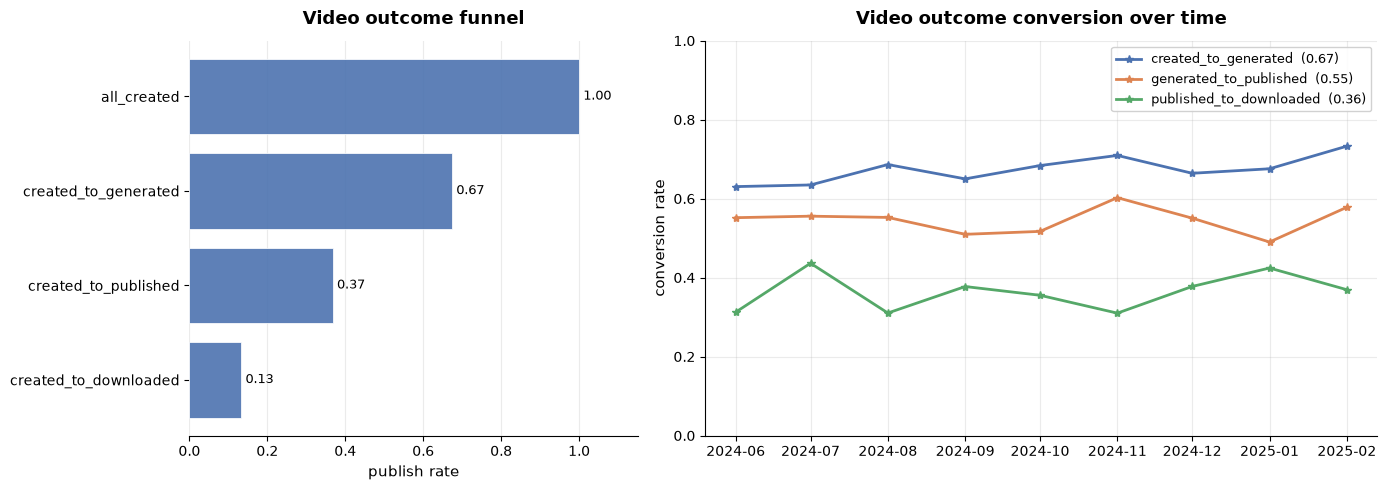

In [8]:
from data_science import visualisation as vis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), 
                               tight_layout=True,
                               gridspec_kw={"width_ratios": [2, 3]})

cols   = ["created_to_generated", "created_to_published", "created_to_downloaded"]
mean_metrics = metrics[cols].mean()
vis.plot_barh(
    labels=['all_created'] + mean_metrics.keys().tolist(), 
    values=np.append(1, mean_metrics.values), 
    xlabel="publish rate",
    title="Video outcome funnel",
    ax=ax1
)

cols = ['created_to_generated', 'generated_to_published', 'published_to_downloaded']
vis.plot_lines(
    x=metrics.index, y=[metrics[c] for c in cols],
    marker='*', labels=cols, ylim=(0, 1),
    ylabel="conversion rate",
    title="Video outcome conversion over time",
    ax=ax2
)

plt.show()

- Publishing strikes the balance as the event indicating succesful conversations
- Downloaded videos were also always published.

generation rate: 67.9%
publish rate: 37.0%
download rate: 13.5%
published_given_downloaded: 100.0%


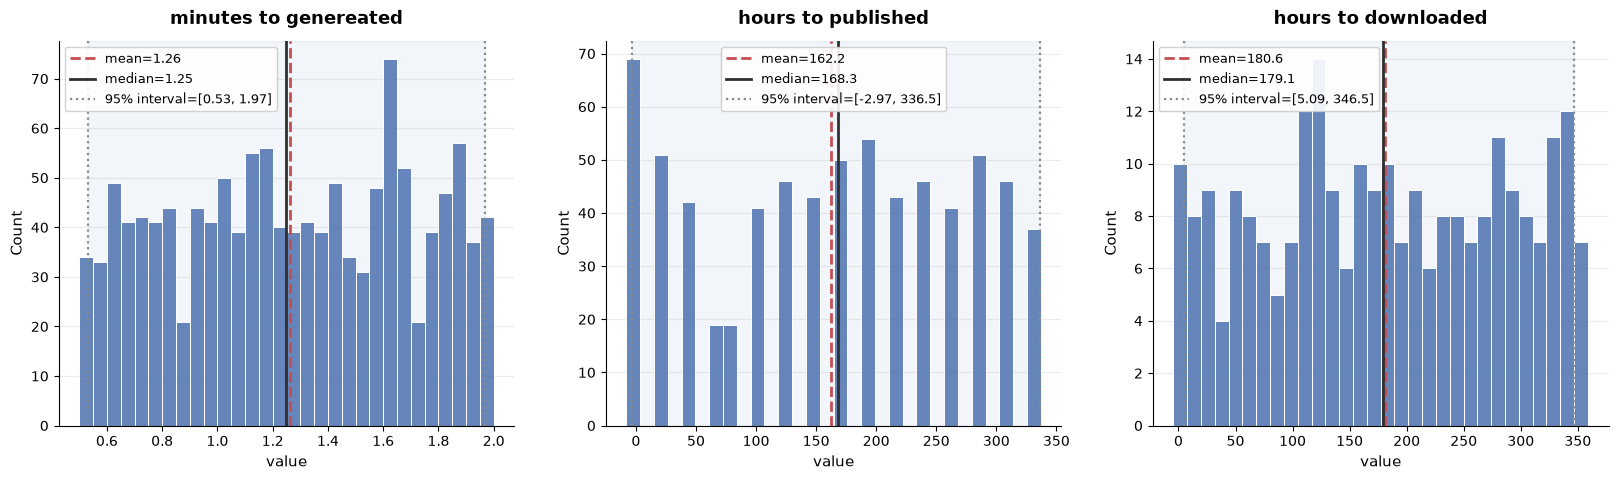

In [9]:
generation_rate = videos_df['generated_at'].notna().mean()
published_rate = videos_df['published_at'].notna().mean()
download_rate = videos_df['downloaded_at'].notna().mean()
published_given_downloaded = (
    ((videos_df['published_at'].notna()) & (videos_df['downloaded_at'].notna())).sum() 
    / videos_df['downloaded_at'].notna().sum()
)

print('generation rate: {:.1f}%'.format(generation_rate*100))
print('publish rate: {:.1f}%'.format(published_rate*100))
print('download rate: {:.1f}%'.format(download_rate*100))
print('published_given_downloaded: {:.1f}%'.format(published_given_downloaded*100))

from data_science.visualisation import plot_histogram

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
plot_histogram(videos_df['minutes_to_generated'], title='minutes to genereated', ax=ax1)
plot_histogram(videos_df['minutes_to_published']/60, title='hours to published', ax=ax2)
plot_histogram(videos_df['minutes_to_downloaded']/60, title='hours to downloaded', ax=ax3)
plt.show()

In [10]:
conversations_df = (
    messages_df.assign(
        is_valid_user_message = (messages_df['role']=='user') & (messages_df['content'].map(lambda x: x==x)),
        is_valid_assistant_message = (messages_df['role']=='assistant') & (messages_df['content'].map(lambda x: x==x)),
    )
    .groupby(['user_id', 'conversation_id', 'video_id']).agg(
        conversation_started_at=('timestamp', 'min'),
        conversation_finished_at=('timestamp', 'max'),
        num_messages=('message_id', 'count'),
        num_user_messages=('role', lambda x: (x=='user').sum()),
        num_assistant_messages=('role', lambda x: (x=='assistant').sum()),
        num_valid_user_messages=('is_valid_user_message', 'sum'),
        num_valid_assistant_messages=('is_valid_assistant_message', 'sum'),
    )
    .reset_index()
)
conversations_df['conversation_duration_minutes'] = ((
    conversations_df['conversation_finished_at']
        - conversations_df['conversation_started_at']
).map(lambda dt: dt.seconds / 60))

print('Total unique conversations: {}'.format(conversations_df.shape[0]))
conversations_df.head()

Total unique conversations: 1885


,user_id,conversation_id,video_id,conversation_started_at,conversation_finished_at,num_messages,num_user_messages,num_assistant_messages,num_valid_user_messages,num_valid_assistant_messages,conversation_duration_minutes
0,usr_009ddeb9,conv_03cf567979,vid_bce2536d0a,2024-06-03 04:50:57,2024-06-03 04:57:39,4,2,2,2,2,6.700000
1,usr_009ddeb9,conv_1227413fa7,vid_ac0e078db7,2024-12-05 23:27:37,2024-12-05 23:36:25,6,3,3,3,3,8.800000
2,usr_009ddeb9,conv_136000d810,vid_dac286dccc,2024-06-13 05:51:35,2024-06-13 06:09:07,10,5,5,5,5,17.533333
3,usr_009ddeb9,conv_1e44eb53f3,vid_8a93103ed7,2025-02-15 22:47:43,2025-02-15 23:03:15,6,3,3,3,3,15.533333
4,usr_009ddeb9,conv_21b277a5de,vid_66cdecddf4,2024-11-29 05:31:45,2024-11-29 05:42:09,6,3,3,2,3,10.400000


In [11]:
daily_convos_per_user = (
    conversations_df.assign(
        conversation_date = conversations_df['conversation_started_at'].dt.date
    )
    .groupby('conversation_date').agg(
        users=('user_id', 'nunique'),
        conversations=('conversation_id', 'nunique')
    )
)
daily_convos_per_user['convos_per_user'] = (
    daily_convos_per_user['conversations'] 
    / daily_convos_per_user['users']
)

In [12]:
user_all_conversations_df = conversations_df.groupby('user_id').agg(
    conversations=('conversation_id', 'count'),
    first_conversation_date = ('conversation_started_at', 'min'),
    last_conversation_date = ('conversation_started_at', 'max'),
)
user_all_conversations_df['days_between_convos'] = (
    (user_all_conversations_df['last_conversation_date'] 
         - user_all_conversations_df['first_conversation_date']).map(lambda dt: dt.days) 
    / (user_all_conversations_df['conversations'] - 1)
)

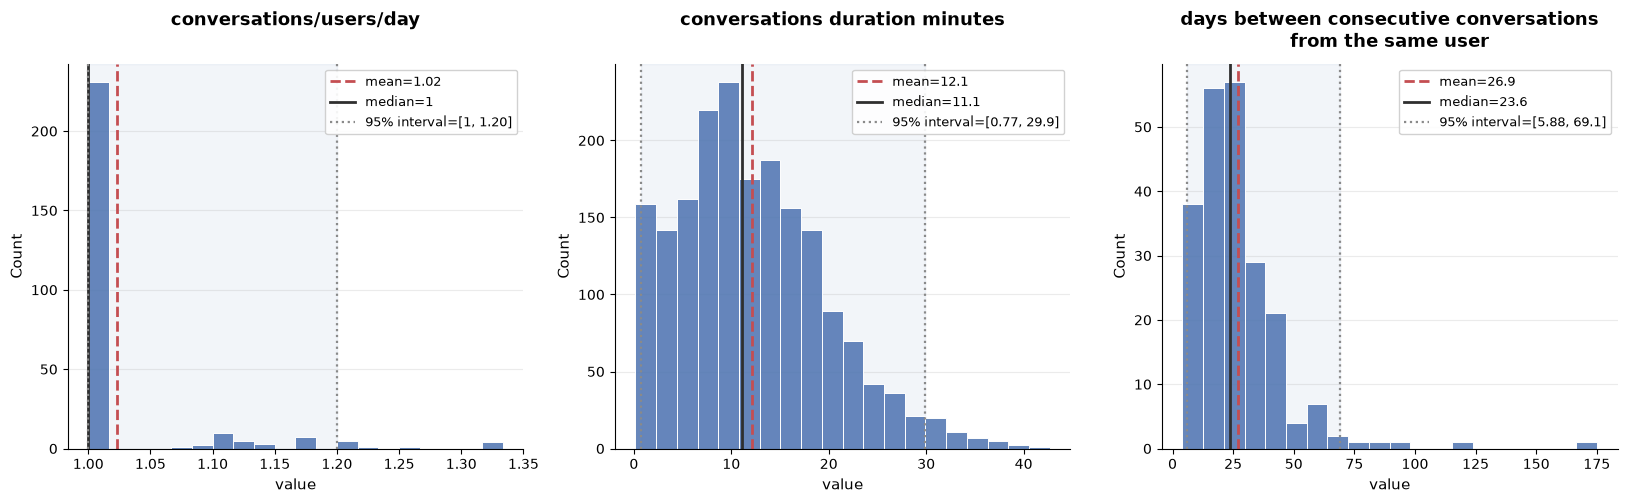

In [13]:
from data_science.visualisation import plot_histogram

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20,5))
plot_histogram(daily_convos_per_user['convos_per_user'], bins=20, title='conversations/users/day\n', ax=ax1)
plot_histogram(conversations_df['conversation_duration_minutes'], bins=20, title='conversations duration minutes\n', ax=ax2)
plot_histogram(user_all_conversations_df['days_between_convos'], bins=20, title='days between consecutive conversations\nfrom the same user', ax=ax3)
plt.show()

Considering:
- Every day each user most likely to have only 1 conversation.
- Conversation spans minutes, not hours nor days, before ended.
- When the same user has multiple conversations, most likely there are at least 6-days (and average 30 days) between 2 consecutive conversations.
  
Therefore, it's safe to assume conversations are independent of each other and can be set as the granularity of the analysis.

## E. Cleaned Data Otuput

In [14]:
users_df.to_csv('../data/processed/users.csv', index=False)
messages_df.to_csv('../data/processed/messages.csv', index=False)
unique_user_messages_content_df.to_csv('../data/processed/unique_user_messages_content.csv', index=False)
videos_df.to_csv('../data/processed/videos.csv', index=False)
conversations_df.to_csv('../data/processed/conversations.csv', index=False)

# End of notebook –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––